splitQP factors the fixed linear system of a box-QP family once, then maps the
same scalar ADMM step across problems that vary only in $q$, $l$, and $u$.
This notebook solves a 64-member portfolio family from one factorization,
rebuilds the same iteration independently, and checks every claim it prints.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import numpy as np

import splitqp

assert jnp.ones(1).dtype == jnp.float64, "x64 must be active before arrays exist"

plt.rcParams.update({
    "font.family": "DejaVu Sans",       # bundled with Matplotlib, reproducible everywhere
    "figure.figsize": (12, 5.625),
    "savefig.dpi": 160,
    "figure.facecolor": "#FAFAF8",
    "axes.facecolor": "#FAFAF8",
    "savefig.facecolor": "#FAFAF8",
    "text.color": "#23272F",
    "axes.edgecolor": "#23272F",
    "axes.labelcolor": "#23272F",
    "xtick.color": "#23272F",
    "ytick.color": "#23272F",
})
BLUE, ORANGE, INK, GRAY, GRID = "#0072B2", "#E69F00", "#23272F", "#8A9099", "#ECEEF0"

The family is a 16-asset Markowitz portfolio: minimize the risk
$\tfrac{1}{2}x^\top\Sigma x$ over allocations $x$ subject to a unit budget,
a minimum expected return, and a 30% position cap. All 64 problems share
$\Sigma$ and the constraint matrix; only the target-return lower bound
changes.

In [2]:
n = 16
mu = np.linspace(0.02, 0.12, n)
vol = np.linspace(0.05, 0.30, n)
idx = np.arange(n)
Sigma = np.diag(vol) @ np.exp(-np.abs(idx[:, None] - idx[None, :]) / 8.0) @ np.diag(vol)
w_max = 0.30

# Rows of A: budget (equality), target return (one-sided), then per-asset caps.
A = np.vstack([np.ones(n), mu, np.eye(n)])

# Highest return reachable under the caps (greedy top holdings), and B targets.
B = 64
r_hi = mu[::-1][:3] @ np.full(3, w_max) + mu[::-1][3] * (1 - 3 * w_max)
targets = np.linspace(mu.min(), 0.98 * r_hi, B)
q = np.zeros((B, n))
l = np.tile(np.concatenate([[1.0, 0.0], np.zeros(n)]), (B, 1))
u = np.tile(np.concatenate([[1.0, np.inf], np.full(n, w_max)]), (B, 1))
l[:, 1] = targets  # the only entry that varies across the family

solver = splitqp.Solver(Sigma, A)  # the single Cholesky factorization

In [3]:
MAX_IT = 20000

batch = solver.solve_batch(q, l, u, max_iter=MAX_IT)
jax.block_until_ready(batch)  # finish async device work before host reads

cold = [solver.solve(q[i], l[i], u[i], max_iter=MAX_IT) for i in range(B)]

warm, state = [], None
for i in range(B):  # ascending targets, each started from the previous solution
    r = solver.solve(q[i], l[i], u[i], init=state, max_iter=MAX_IT)
    warm.append(r)
    state = r.state

In [4]:
x = np.asarray(batch.x)  # one explicit host conversion for all checks below
iters_batch = np.asarray(batch.iterations)
iters_cold = np.array([int(r.iterations) for r in cold])
iters_warm = np.array([int(r.iterations) for r in warm])

assert bool(np.all(np.asarray(batch.converged)))
assert all(bool(r.converged) for r in cold + warm)
assert solver.factorizations == 1, "every solve above must reuse one factor"

max_kkt = max(float(np.max(np.asarray(batch.r_primal))),
              float(np.max(np.asarray(batch.r_dual))))
assert max_kkt < 1e-5

batch_vs_scalar = max(float(np.max(np.abs(x[i] - np.asarray(cold[i].x))))
                      for i in range(B))
assert batch_vs_scalar < 1e-8
assert np.array_equal(iters_batch, iters_cold), "frozen lanes must match scalar stops"

assert iters_warm.sum() < iters_cold.sum(), "warm starts must shorten the sweep"
returns = x @ mu
risks = np.sqrt(np.einsum("bi,ij,bj->b", x, Sigma, x))
assert np.all(returns >= targets - 1e-5)
assert np.allclose(x.sum(axis=1), 1.0, atol=1e-5)
assert np.all(x >= -1e-5) and np.all(x <= w_max + 1e-5)
assert np.all(np.diff(risks) > -1e-9)

print(f"{B} QPs, {solver.factorizations} factorization")
print(f"max KKT residual: {max_kkt:.2e}")
print(f"batch/scalar difference: {batch_vs_scalar:.2e}")
print(f"cold iterations vs warm sequence: {iters_cold.sum()} vs {iters_warm.sum()}")

64 QPs, 1 factorization
max KKT residual: 2.00e-06
batch/scalar difference: 3.44e-15
cold iterations vs warm sequence: 48435 vs 36184


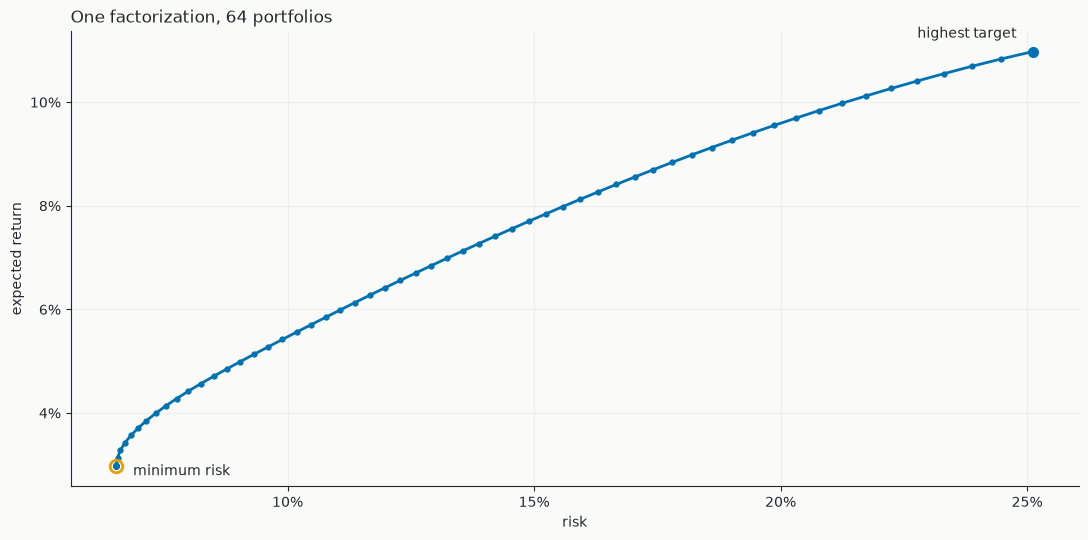

In [5]:
# The visual claims, asserted before anything is drawn.
assert len(risks) == len(returns) == B and bool(np.all(np.asarray(batch.converged)))
assert np.allclose(risks, np.sqrt(np.einsum("bi,ij,bj->b", x, Sigma, x)))
assert np.allclose(returns, x @ mu)
assert np.all(returns >= targets - 1e-5)
assert np.allclose(x.sum(axis=1), 1.0, atol=1e-5)
assert np.all(x >= -1e-5) and np.all(x <= w_max + 1e-5)
assert np.all(np.diff(risks) > -1e-9)
assert batch_vs_scalar < 1e-8 and max_kkt < 1e-5 and solver.factorizations == 1

from pathlib import Path

Path("assets").mkdir(exist_ok=True)
i_min, i_max = int(np.argmin(risks)), B - 1

fig, ax = plt.subplots()
fig.subplots_adjust(left=0.065, right=0.905, top=0.92, bottom=0.11)  # fixed layout: both PNGs are exactly 1920x900
ax.plot(risks, returns, color=BLUE, lw=2, marker="o", ms=3.5)
ax.plot(risks[i_min], returns[i_min], "o", ms=9, mfc="none", mec=ORANGE, mew=2, zorder=3)
ax.annotate("minimum risk", (risks[i_min], returns[i_min]),
            xytext=(12, -4), textcoords="offset points", va="center", color=INK)
ax.plot(risks[i_max], returns[i_max], "o", ms=7, color=BLUE, zorder=3)
ax.annotate("highest target", (risks[i_max], returns[i_max]),
            xytext=(-12, 10), textcoords="offset points", ha="right", color=INK)
ax.set_title("One factorization, 64 portfolios", loc="left", color=INK)
ax.set_xlabel("risk")
ax.set_ylabel("expected return")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.xaxis.set_major_locator(mtick.MaxNLocator(5))
ax.yaxis.set_major_locator(mtick.MaxNLocator(5))
ax.grid(color=GRID, lw=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_linewidth(0.8)
fig.savefig("assets/frontier.png", dpi=160,
            metadata={"Software": "splitqp portfolio.ipynb"})
display(fig)
plt.close(fig)

One ADMM iteration is six updates:

$$
\begin{aligned}
H\tilde{x} &= \sigma x - q + A^{\top}(\rho z - y),
    \qquad H = P + \sigma I + \rho A^{\top}A \\
\tilde{z} &= A\tilde{x} \\
x^{+} &= \alpha\tilde{x} + (1-\alpha)x \\
\bar{z} &= \alpha\tilde{z} + (1-\alpha)z \\
z^{+} &= \Pi_{[l,u]}(\bar{z} + y/\rho) \\
y^{+} &= y + \rho(\bar{z} - z^{+})
\end{aligned}
$$

The Solver factors $H$ once at construction and reuses the triangular factor
in every iteration. The reference below re-solves $H\tilde{x} = \text{rhs}$
from scratch with `jnp.linalg.solve` every iteration, so the two paths share
nothing but these equations.

In [6]:
def solve_reference(P, A, q, l, u, *, rho=0.1, sigma=1e-6, alpha=1.6,
                    eps_abs=1e-6, eps_rel=1e-6, max_iter=4000, init=None):
    """The six updates, one equation per line, with a fresh dense solve every
    iteration; keeps every named intermediate for quantity-by-quantity audit."""
    inf = lambda w: jnp.max(jnp.abs(w))
    n, m = q.shape[0], l.shape[0]
    H = P + sigma * jnp.eye(n) + rho * A.T @ A
    x, z, y = (jnp.zeros(n), jnp.zeros(m), jnp.zeros(m)) if init is None else init
    trace = []
    for k in range(1, max_iter + 1):
        rhs = sigma * x - q + A.T @ (rho * z - y)
        x_tilde = jnp.linalg.solve(H, rhs)
        z_tilde = A @ x_tilde
        x = alpha * x_tilde + (1 - alpha) * x
        z_bar = alpha * z_tilde + (1 - alpha) * z
        v = z_bar + y / rho
        z = jnp.clip(v, l, u)
        y = y + rho * (z_bar - z)
        # Residuals have optimality meaning only now, after z became a box
        # projection; a raw zero initialization would pass them vacuously.
        Ax, Px, Aty = A @ x, P @ x, A.T @ y
        r_primal, r_dual = Ax - z, Px + q + Aty
        eps_primal = eps_abs + eps_rel * jnp.maximum(inf(Ax), inf(z))
        eps_dual = eps_abs + eps_rel * jnp.maximum(inf(Px), jnp.maximum(inf(Aty), inf(q)))
        converged = bool((inf(r_primal) <= eps_primal) & (inf(r_dual) <= eps_dual))
        trace.append(dict(iteration=k, rhs=rhs, x_tilde=x_tilde, z_tilde=z_tilde,
                          x=x, z_bar=z_bar, v=v, z=z, y=y,
                          objective=0.5 * x @ (P @ x) + q @ x,
                          r_primal=r_primal, r_dual=r_dual,
                          eps_primal=eps_primal, eps_dual=eps_dual,
                          converged=converged))
        if converged:
            break
    return x, z, y, trace

In [7]:
from fractions import Fraction as F

# A two-variable integer QP with rho=2, sigma=1, alpha=3/2 keeps the whole
# first step inside exact rational arithmetic.
P2 = jnp.array([[4.0, 0.0], [0.0, 2.0]])
A2 = jnp.array([[1.0, 1.0], [1.0, 0.0]])
q2 = jnp.array([-8.0, -6.0])
l2 = jnp.array([1.0, 0.0])
u2 = jnp.array([1.0, 0.75])

rho, sigma, alpha = F(2), F(1), F(3, 2)
Pf = [[F(4), F(0)], [F(0), F(2)]]
Af = [[F(1), F(1)], [F(1), F(0)]]
qf = [F(-8), F(-6)]
lf, uf = [F(1), F(0)], [F(1), F(3, 4)]

AtA = [[sum(Af[k][i] * Af[k][j] for k in range(2)) for j in range(2)] for i in range(2)]
Hf = [[Pf[i][j] + (sigma if i == j else F(0)) + rho * AtA[i][j]
       for j in range(2)] for i in range(2)]
rhs_f = [-w for w in qf]                                    # from x = z = y = 0
det = Hf[0][0] * Hf[1][1] - Hf[0][1] * Hf[1][0]
x_tilde_f = [(Hf[1][1] * rhs_f[0] - Hf[0][1] * rhs_f[1]) / det,
             (Hf[0][0] * rhs_f[1] - Hf[1][0] * rhs_f[0]) / det]
z_tilde_f = [sum(Af[i][j] * x_tilde_f[j] for j in range(2)) for i in range(2)]
x_f = [alpha * w for w in x_tilde_f]
z_bar_f = [alpha * w for w in z_tilde_f]
v_f = list(z_bar_f)                                         # y = 0
z_f = [min(max(v_f[i], lf[i]), uf[i]) for i in range(2)]
y_f = [rho * (z_bar_f[i] - z_f[i]) for i in range(2)]
assert Hf == [[F(9), F(2)], [F(2), F(5)]] and det == F(41)
assert x_tilde_f == [F(28, 41), F(38, 41)] and z_f == [F(1), F(3, 4)]
assert y_f == [F(116, 41), F(45, 82)]

solver2 = splitqp.Solver(P2, A2, rho=2.0, sigma=1.0, alpha=1.5)
state1, parts1 = splitqp.step(solver2.cache, q2, l2, u2,
                              splitqp.State(jnp.zeros(2), jnp.zeros(2), jnp.zeros(2)))
exact = dict(rhs=rhs_f, x_tilde=x_tilde_f, z_tilde=z_tilde_f, x=x_f,
             z_bar=z_bar_f, v=v_f, z=z_f, y=y_f)
got = dict(rhs=parts1.rhs, x_tilde=parts1.x_tilde, z_tilde=parts1.z_tilde,
           x=state1.x, z_bar=parts1.z_bar, v=parts1.v, z=state1.z, y=state1.y)
for name in exact:
    np.testing.assert_allclose(np.asarray(got[name]),
                               np.array([float(w) for w in exact[name]]),
                               rtol=1e-13, atol=1e-14, err_msg=name)

# The eager reference's first iteration matches the same exact fractions.
_, _, _, ref1 = solve_reference(P2, A2, q2, l2, u2, rho=2.0, sigma=1.0,
                                alpha=1.5, max_iter=1)
for name in exact:
    np.testing.assert_allclose(np.asarray(ref1[0][name]),
                               np.array([float(w) for w in exact[name]]),
                               rtol=1e-13, atol=1e-14, err_msg=f"reference {name}")
print("first step matches exact fractions: "
      f"x_tilde = ({x_tilde_f[0]}, {x_tilde_f[1]}), "
      f"z = ({z_f[0]}, {z_f[1]}), y = ({y_f[0]}, {y_f[1]})")

first step matches exact fractions: x_tilde = (28/41, 38/41), z = (1, 3/4), y = (116/41, 45/82)


In [8]:
# A seeded 8-variable, 12-constraint QP; the box is drawn around an attainable
# A @ x0, so the problem is feasible by construction.
rng = np.random.default_rng(7)
n8, m8 = 8, 12
M = rng.normal(size=(n8, n8))
P8 = jnp.asarray(M @ M.T + n8 * np.eye(n8))
A8 = jnp.asarray(rng.normal(size=(m8, n8)))
q8 = jnp.asarray(rng.normal(size=n8))
c0 = np.asarray(A8) @ rng.normal(size=n8)
l8 = jnp.asarray(c0 - rng.uniform(0.1, 1.0, size=m8))
u8 = jnp.asarray(c0 + rng.uniform(0.1, 1.0, size=m8))

# Thirty iterations of the cached path: every named intermediate equals the
# fresh-solve reference.
solver8 = splitqp.Solver(P8, A8)
_, _, _, ref = solve_reference(P8, A8, q8, l8, u8, max_iter=30)
state = splitqp.State(jnp.zeros(n8), jnp.zeros(m8), jnp.zeros(m8))
for k in range(30):
    state, parts = splitqp.step(solver8.cache, q8, l8, u8, state)
    rep = splitqp.report(solver8.cache, q8, l8, u8, state, 1e-6, 1e-6)
    r = ref[k]
    named = dict(rhs=parts.rhs, x_tilde=parts.x_tilde, z_tilde=parts.z_tilde,
                 x=state.x, z_bar=parts.z_bar, v=parts.v, z=state.z, y=state.y,
                 objective=rep.objective, r_primal=rep.r_primal,
                 r_dual=rep.r_dual, eps_primal=rep.eps_primal,
                 eps_dual=rep.eps_dual)
    for name, val in named.items():
        np.testing.assert_allclose(np.asarray(val), np.asarray(r[name]),
                                   rtol=1e-9, atol=1e-11,
                                   err_msg=f"iteration {k + 1}: {name}")
    assert bool(rep.converged) == r["converged"]

In [9]:
# jit(step) agrees with the eager step it traced.
jit_step = jax.jit(splitqp.step)
s0 = splitqp.State(jnp.zeros(n8), jnp.zeros(m8), jnp.zeros(m8))
eager_out = splitqp.step(solver8.cache, q8, l8, u8, s0)
jit_out = jit_step(solver8.cache, q8, l8, u8, s0)
for a, b in zip(eager_out[0] + eager_out[1], jit_out[0] + jit_out[1]):
    np.testing.assert_allclose(np.asarray(a), np.asarray(b), rtol=1e-12, atol=1e-14)

# Compiled while_loop, host trace loop, and the reference accept the same stop.
res_loop = solver8.solve(q8, l8, u8)
res_trace, trace = solver8.trace(q8, l8, u8)
_, _, _, ref_full = solve_reference(P8, A8, q8, l8, u8)
assert bool(res_loop.converged) and bool(res_trace.converged)
assert int(res_loop.iterations) == int(res_trace.iterations) == len(ref_full)
np.testing.assert_allclose(np.asarray(res_loop.x), np.asarray(res_trace.x),
                           rtol=1e-10, atol=1e-12)
np.testing.assert_allclose(np.asarray(res_trace.x), np.asarray(ref_full[-1]["x"]),
                           rtol=1e-8, atol=1e-10)
assert trace.x.shape[0] == int(res_trace.iterations)

# Five feasible QPs sharing the cache: jit(vmap(step)) equals a Python stack
# of scalar steps; in_axes=None shares the cache, 0 maps each lane's data.
B5 = 5
qb = jnp.asarray(rng.normal(size=(B5, n8)))
cb = (np.asarray(A8) @ rng.normal(size=(B5, n8)).T).T
lb = jnp.asarray(cb - rng.uniform(0.1, 1.0, size=(B5, m8)))
ub = jnp.asarray(cb + rng.uniform(0.1, 1.0, size=(B5, m8)))
batched_step = jax.jit(jax.vmap(splitqp.step, in_axes=(None, 0, 0, 0, 0)))
sb = splitqp.State(jnp.zeros((B5, n8)), jnp.zeros((B5, m8)), jnp.zeros((B5, m8)))
for _ in range(10):
    sb, _ = batched_step(solver8.cache, qb, lb, ub, sb)
for i in range(B5):
    si = splitqp.State(jnp.zeros(n8), jnp.zeros(m8), jnp.zeros(m8))
    for _ in range(10):
        si, _ = splitqp.step(solver8.cache, qb[i], lb[i], ub[i], si)
    for a, b in zip((sb.x[i], sb.z[i], sb.y[i]), si):
        np.testing.assert_allclose(np.asarray(a), np.asarray(b), rtol=1e-10, atol=1e-12)

# Batch lanes freeze at their first accepted stop and equal independently
# stopped scalar solves, iteration count included.
res_b = solver8.solve_batch(qb, lb, ub, max_iter=30000)
assert bool(jnp.all(res_b.converged))
for i in range(B5):
    r_i = solver8.solve(qb[i], lb[i], ub[i], max_iter=30000)
    assert int(res_b.iterations[i]) == int(r_i.iterations)
    np.testing.assert_allclose(np.asarray(res_b.x[i]), np.asarray(r_i.x),
                               rtol=1e-9, atol=1e-11)

# Projection invariant: z = clip(z + y/rho, l, u) holds at every solution.
z_proj = jnp.clip(res_b.z + res_b.y / solver8.cache.rho, lb, ub)
np.testing.assert_allclose(np.asarray(res_b.z), np.asarray(z_proj), rtol=0, atol=1e-9)

# A solution is a fixed point of the step: warm-starting from it is accepted
# after a single confirming iteration.
warm_fp = solver8.solve(qb[0], lb[0], ub[0],
                        init=splitqp.State(res_b.x[0], res_b.z[0], res_b.y[0]))
assert int(warm_fp.iterations) == 1 and bool(warm_fp.converged)

assert solver8.factorizations == 1, "the whole ladder reused one setup"
print("checks okay: 30 audited iterations, eager = jit, vmap = stack, "
      f"loop = trace = reference stop ({int(res_loop.iterations)} iterations), "
      f"lanes {[int(i) for i in res_b.iterations]} frozen = scalar, "
      "projection and warm-start fixed point hold, 1 factorization")

checks okay: 30 audited iterations, eager = jit, vmap = stack, loop = trace = reference stop (3751 iterations), lanes [722, 3041, 1886, 1189, 23410] frozen = scalar, projection and warm-start fixed point hold, 1 factorization


In [10]:
import osqp
import scipy.sparse as sparse

for Pi, Ai, qi, li, ui, ours in [
    (P2, A2, q2, l2, u2, splitqp.Solver(P2, A2).solve(q2, l2, u2)),
    (P8, A8, q8, l8, u8, res_loop),
]:
    oracle = osqp.OSQP()
    oracle.setup(sparse.csc_matrix(np.asarray(Pi)), np.asarray(qi),
                 sparse.csc_matrix(np.asarray(Ai)), np.asarray(li),
                 np.asarray(ui), eps_abs=1e-9, eps_rel=1e-9, rho=0.1,
                 sigma=1e-6, alpha=1.6, adaptive_rho=False, scaling=0,
                 polishing=False, verbose=False, max_iter=200000)
    osqp_res = oracle.solve()
    assert osqp_res.info.status == "solved" and bool(ours.converged)
    np.testing.assert_allclose(float(ours.objective), osqp_res.info.obj_val,
                               rtol=1e-6, atol=1e-5)
    # Our final point satisfies the original-scale KKT conditions on its own.
    assert float(ours.r_primal) < 1e-4 and float(ours.r_dual) < 1e-4
print("OSQP okay: objectives and original-scale KKT residuals agree on both QPs")

OSQP okay: objectives and original-scale KKT residuals agree on both QPs


Adjacent targets move the optimum only a little along the frontier, so the
previous $(x, z, y)$ already nearly satisfies the next problem's optimality
conditions. Reusing it shortens the sweep while the factor stays untouched.

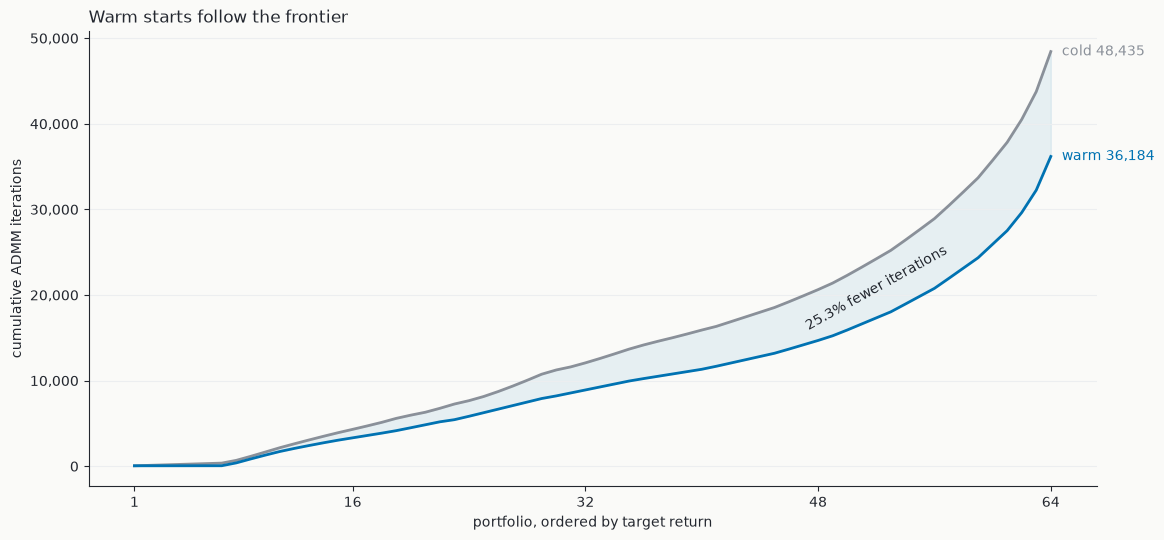

In [11]:
# The visual claims, asserted before anything is drawn.
cum_cold = np.cumsum(iters_cold)
cum_warm = np.cumsum(iters_warm)
total_cold, total_warm = int(cum_cold[-1]), int(cum_warm[-1])
saving = 100.0 * (total_cold - total_warm) / total_cold
assert all(bool(r.converged) for r in cold + warm)
assert np.array_equal(iters_batch, iters_cold), "cold scalar stops must equal batch lanes"
assert iters_warm[0] == iters_cold[0], "the first warm solve starts cold"
assert np.all(np.diff(cum_cold) > 0) and np.all(np.diff(cum_warm) > 0)
assert total_warm < total_cold
assert solver.factorizations == 1, "the sweep reused the one Cache"

pos = np.arange(1, B + 1)
fig, ax = plt.subplots()
fig.subplots_adjust(left=0.065, right=0.905, top=0.92, bottom=0.11)  # fixed layout: both PNGs are exactly 1920x900
ax.plot(pos, cum_cold, color=GRAY, lw=2)
ax.plot(pos, cum_warm, color=BLUE, lw=2)
ax.fill_between(pos, cum_warm, cum_cold, color=BLUE, alpha=0.08)
ax.annotate(f"cold {total_cold:,}", (B, total_cold), xytext=(8, 0),
            textcoords="offset points", va="center", color=GRAY)
ax.annotate(f"warm {total_warm:,}", (B, total_warm), xytext=(8, 0),
            textcoords="offset points", va="center", color=BLUE)
ax.set_title("Warm starts follow the frontier", loc="left", color=INK)
ax.set_xlabel("portfolio, ordered by target return")
ax.set_ylabel("cumulative ADMM iterations")
ax.set_xticks([1, 16, 32, 48, 64])
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", color=GRID, lw=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_linewidth(0.8)

# Lay the saving label along the gap it measures: the angle of the mid-band
# chord in display coordinates, computed once the axes limits are final.
mid = (cum_cold + cum_warm) / 2
a, b = 44, 58
pts = ax.transData.transform(np.column_stack([pos[[a, b]], mid[[a, b]]]))
angle = np.degrees(np.arctan2(pts[1, 1] - pts[0, 1], pts[1, 0] - pts[0, 0]))
k_mid = (a + b) // 2
ax.annotate(f"{saving:.1f}% fewer iterations", (pos[k_mid], mid[k_mid]),
            ha="center", va="center", color=INK,
            rotation=angle, rotation_mode="anchor")
fig.savefig("assets/warm_start.png", dpi=160,
            metadata={"Software": "splitqp portfolio.ipynb"})
display(fig)
plt.close(fig)

splitQP deliberately stops here: no sparse matrices, scaling, adaptive
$\rho$, infeasibility certificates, polishing, matrix updates, alternate
linear solvers, modeling language, or autodiff layer, and no second
algorithm. What remains is the one relationship shown above: a single
factorization serving a whole family of box QPs.